# LAB 05: PHÂN ĐOẠN ẢNH (IMAGE SEGMENTATION)

In [1]:
import cv2 as cv
import matplotlib.pyplot as Phat

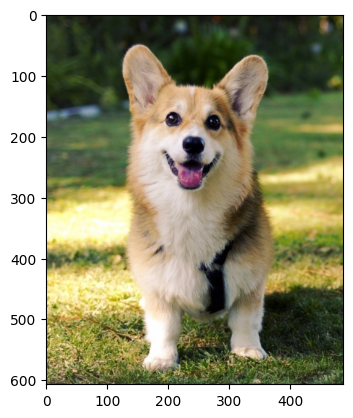

In [3]:
img = cv.imread('dog.jpg')
img = img[:,:,::-1]
Phat.imshow(img)


## 1. Thresholding để phân đoạn ảnh

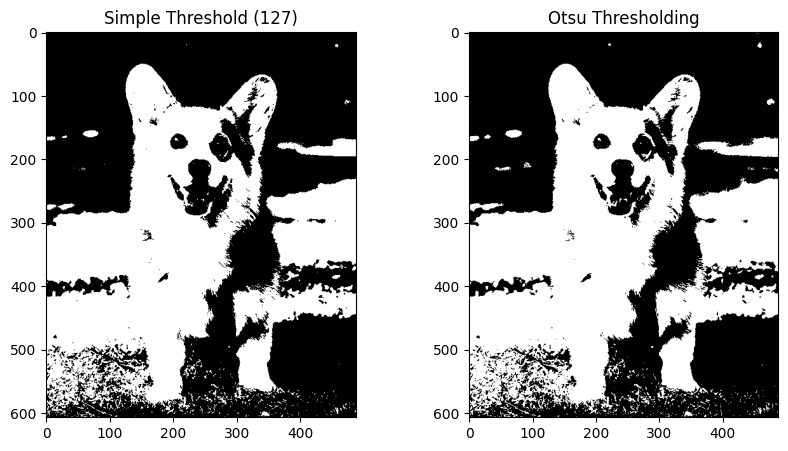

In [14]:
gray = cv.cvtColor(img, cv.COLOR_RGB2GRAY)

ret, thresh_simple = cv.threshold(gray, 127, 255, cv.THRESH_BINARY)

ret2, thresh_otsu = cv.threshold(gray, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

Phat.figure(figsize=(10, 5))
Phat.subplot(1, 2, 1)
Phat.title("Simple Threshold (127)")
Phat.imshow(thresh_simple, cmap='gray')

Phat.subplot(1, 2, 2)
Phat.title("Otsu Thresholding")
Phat.imshow(thresh_otsu, cmap='gray')
Phat.show()

## 2. Otsu algorithm để phân đoạn ảnh vân tay

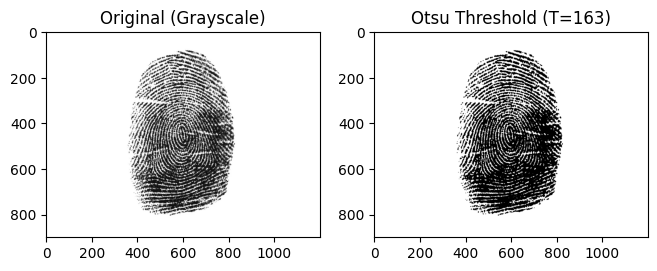

In [17]:
import cv2 as cv
import matplotlib.pyplot as Phat


img_finger = cv.imread('vantay.webp', 0)

blur = cv.GaussianBlur(img_finger, (5, 5), 0)

ret, thresh = cv.threshold(blur, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

Phat.figure(figsize=(12, 6))
Phat.subplot(1, 3, 1)
Phat.title("Original (Grayscale)")
Phat.imshow(img_finger, cmap='gray')

Phat.subplot(1, 3, 2)
Phat.title(f"Otsu Threshold (T={int(ret)})")
Phat.imshow(thresh, cmap='gray')
Phat.show()

## 3. Clustering techniques trong phân đoạn ảnh, K-mean clustering

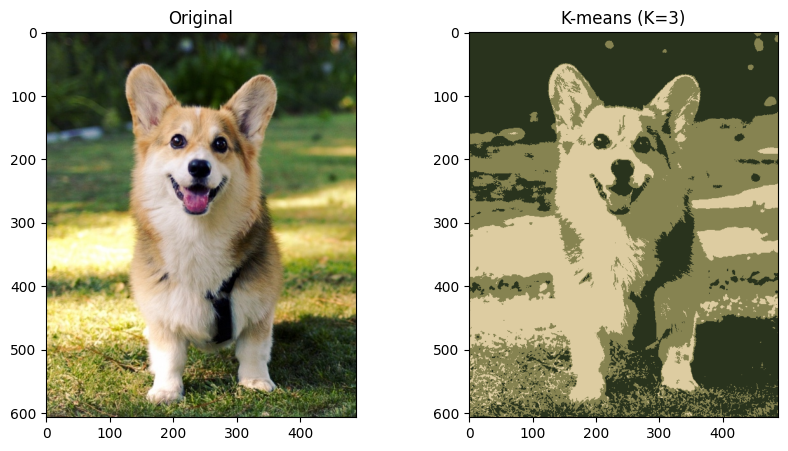

In [18]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as Phat

img = cv.imread('dog.jpg')
img = img[:,:,::-1]

data = img.reshape((-1, 3))
data = np.float32(data)

criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 100, 0.2)

K = 3
ret, label, center = cv.kmeans(data, K, None, criteria, 10, cv.KMEANS_RANDOM_CENTERS)

center = np.uint8(center)
res = center[label.flatten()]
res2 = res.reshape((img.shape))

Phat.figure(figsize=(10, 5))
Phat.subplot(1, 2, 1), Phat.title("Original"), Phat.imshow(img)
Phat.subplot(1, 2, 2), Phat.title(f"K-means (K={K})"), Phat.imshow(res2)
Phat.show()

## 4. Sử dụng thuật toán Region growing

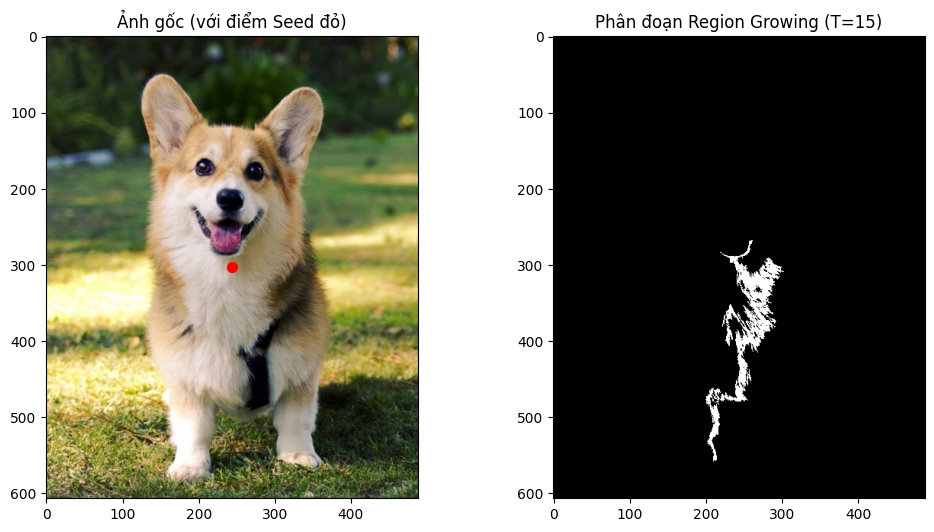

In [9]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as Phat

def region_growing(img, seed, threshold):
    h, w = img.shape
    segmented = np.zeros_like(img)
    list_points = [seed]
    seed_value = img[seed]
    segmented[seed] = 255

    while len(list_points) > 0:
        pix = list_points.pop(0)

        for x in range(-1, 2):
            for y in range(-1, 2):
                curr_x, curr_y = pix[0] + x, pix[1] + y

                if 0 <= curr_x < h and 0 <= curr_y < w:
                    if segmented[curr_x, curr_y] == 0:
                        diff = abs(int(img[curr_x, curr_y]) - int(seed_value))
                        if diff < threshold:
                            segmented[curr_x, curr_y] = 255
                            list_points.append((curr_x, curr_y))
    return segmented

img_input = cv.imread('dog.jpg')
gray = cv.cvtColor(img_input, cv.COLOR_BGR2GRAY)
img_rgb = cv.cvtColor(img_input, cv.COLOR_BGR2RGB)

h, w = gray.shape
seed = (h // 2, w // 2)
threshold = 15

result = region_growing(gray, seed, threshold)

Phat.figure(figsize=(12, 6))

Phat.subplot(1, 2, 1)
Phat.title("Ảnh gốc (với điểm Seed đỏ)")
Phat.imshow(img_rgb)
Phat.scatter(seed[1], seed[0], color='red', s=50)

Phat.subplot(1, 2, 2)
Phat.title(f"Phân đoạn Region Growing (T={threshold})")
Phat.imshow(result, cmap='gray')

Phat.show()

## 5. Sử dụng thuật toán Split and merge để phân đoạn ảnh

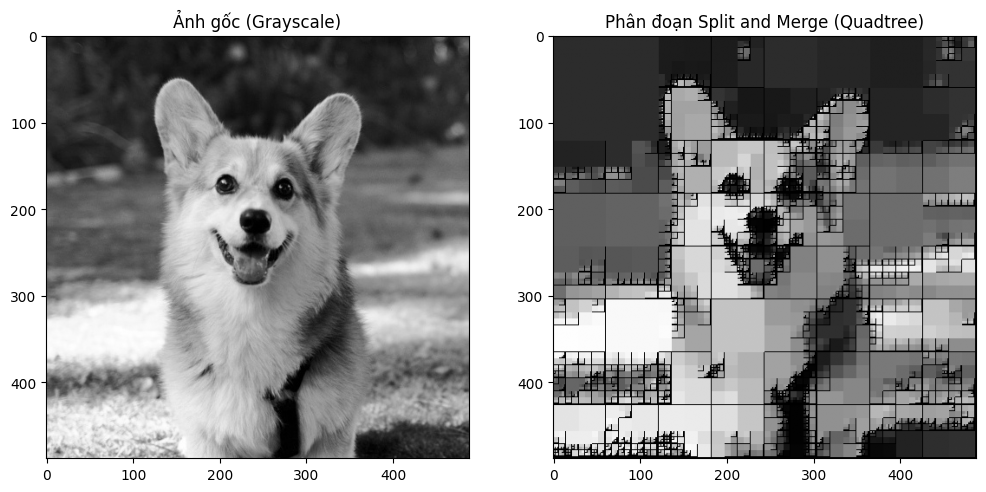

In [10]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as Phat

def check_homogeneity(region, threshold):

    return np.std(region) < threshold

def split_region(img, x, y, w, h, threshold, mask):
    region = img[y:y+h, x:x+w]
    if check_homogeneity(region, threshold) or w <= 2 or h <= 2:

        mask[y:y+h, x:x+w] = np.mean(region)
    else:

        w2, h2 = w // 2, h // 2
        split_region(img, x, y, w2, h2, threshold, mask)
        split_region(img, x + w2, y, w2, h2, threshold, mask)
        split_region(img, x, y + h2, w2, h2, threshold, mask)
        split_region(img, x + w2, y + h2, w2, h2, threshold, mask)

img_input = cv.imread('dog.jpg', 0)
h, w = img_input.shape

size = min(h, w)
img_square = img_input[:size, :size]
segmented_mask = np.zeros_like(img_square)

split_region(img_square, 0, 0, size, size, 15, segmented_mask)

Phat.figure(figsize=(12, 6))

Phat.subplot(1, 2, 1)
Phat.title("Ảnh gốc (Grayscale)")
Phat.imshow(img_square, cmap='gray')

Phat.subplot(1, 2, 2)
Phat.title("Phân đoạn Split and Merge (Quadtree)")
Phat.imshow(segmented_mask, cmap='gray')

Phat.show()

## 6. Phân đoạn ảnh với Edge-based segmentation


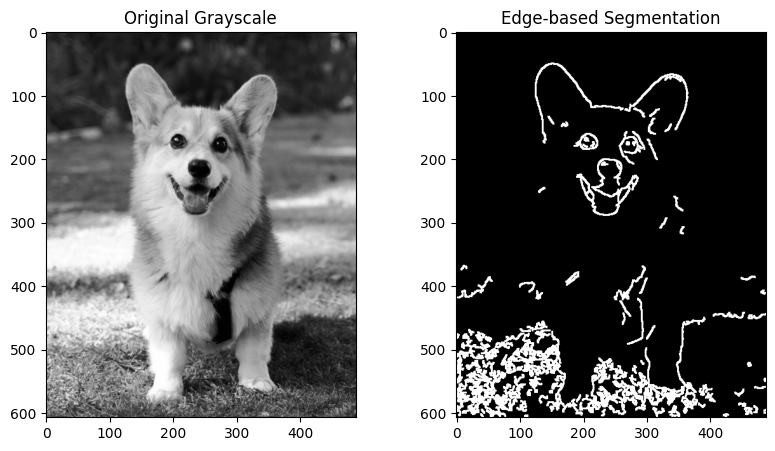

In [12]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as Phat

img_input = cv.imread('dog.jpg')
gray = cv.cvtColor(img_input, cv.COLOR_BGR2GRAY)

blur = cv.GaussianBlur(gray, (5, 5), 0)

edges = cv.Canny(blur, 100, 200)

kernel = np.ones((3,3), np.uint8)
dilated = cv.dilate(edges, kernel, iterations=1)

Phat.figure(figsize=(15, 5))
Phat.subplot(1, 3, 1)
Phat.title("Original Grayscale")
Phat.imshow(gray, cmap='gray')


Phat.subplot(1, 3, 2)
Phat.title("Edge-based Segmentation")
Phat.imshow(dilated, cmap='gray')
Phat.show()